In [1]:
from utils import *
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
# print(get_algorithms_classes(Experiment.bell_state_reach, "convex"))

In [12]:
dump_all_summary_specs()

In [13]:
for experiment in Experiment:
    dump_stats_summary(experiment)

In [14]:
dump_summary_table("bellman", save=True)
dump_summary_table("convex", save=True)

,experiment,horizon,#hard.,#emb.,#diff. algo.,#improv.,max. improv.,avg. build time,max. build time,avg. method time,max. method time
0,state discr.,6,55,109,483,648,0.24214,0.03108,0.66285,217.72536,8434.0
1,Bell state reach,6,45,136,48,283,0.24732,0.21887,1.09533,17.30675,83.0
2,Reset,7,55,109,478,714,0.39286,0.00223,0.50000,6.72375,430.0


In [15]:
for experiment in Experiment:
    dump_stats_summary(experiment)

# Visualization of optimal algorithms vs perfect-optimal

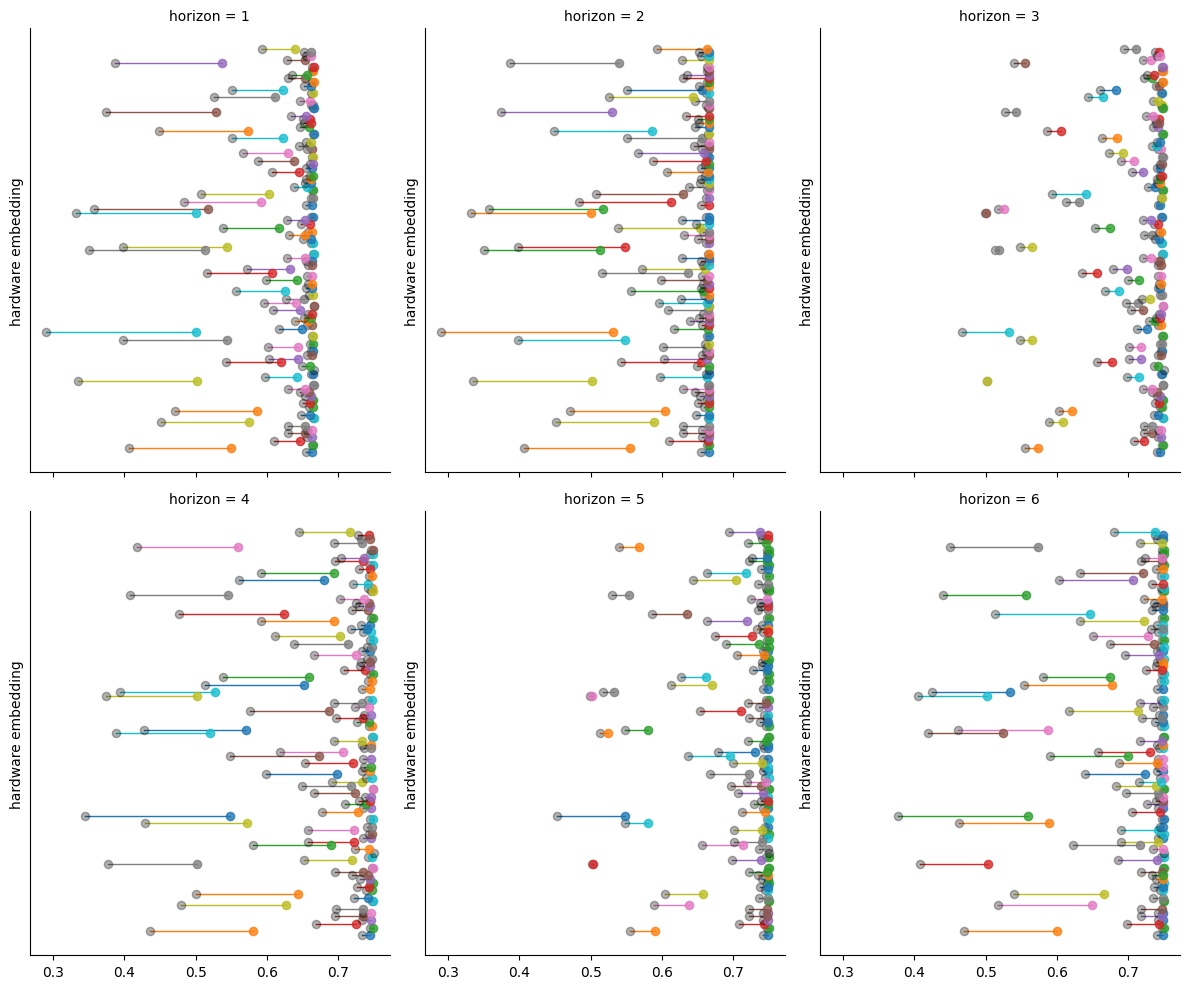

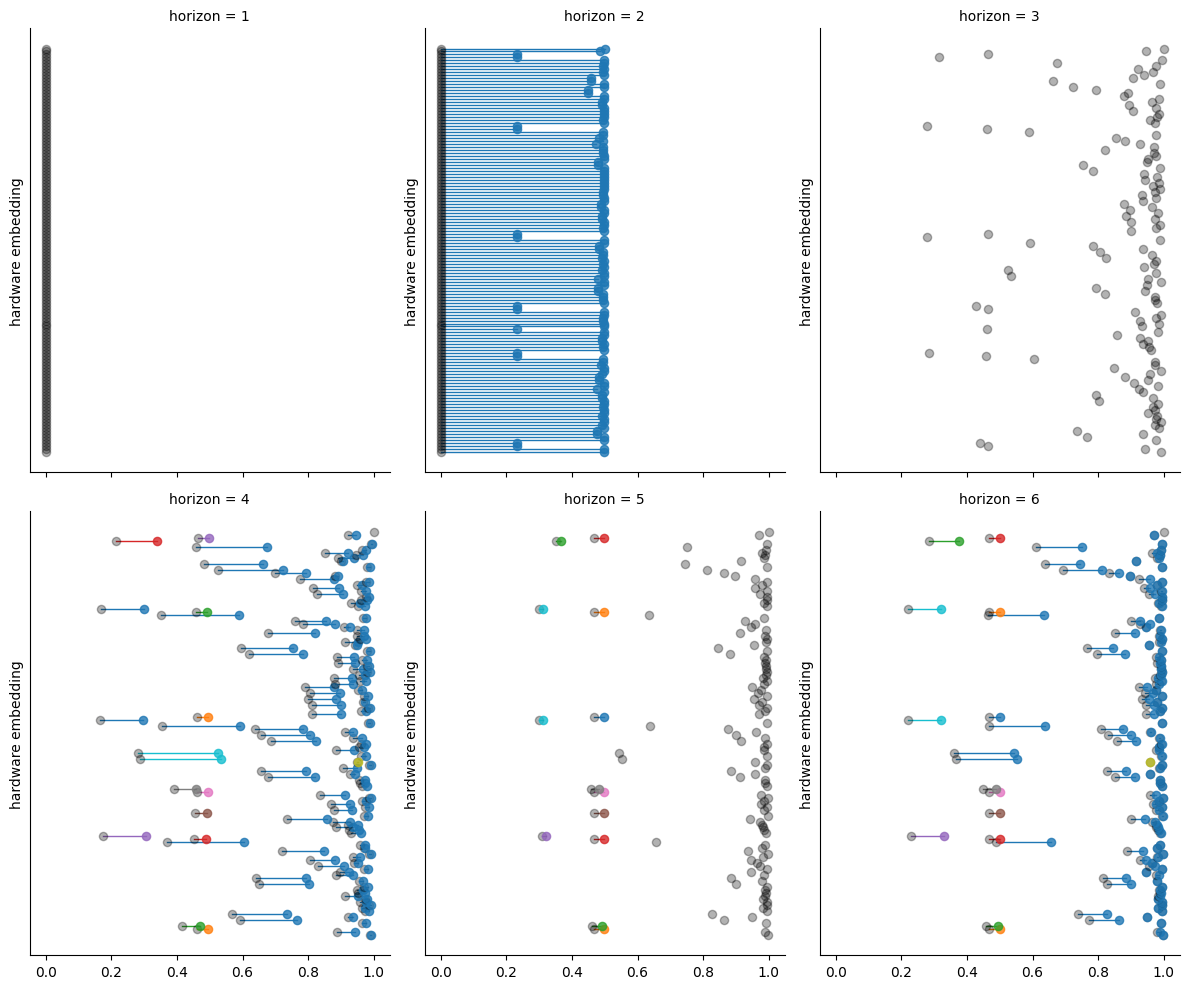

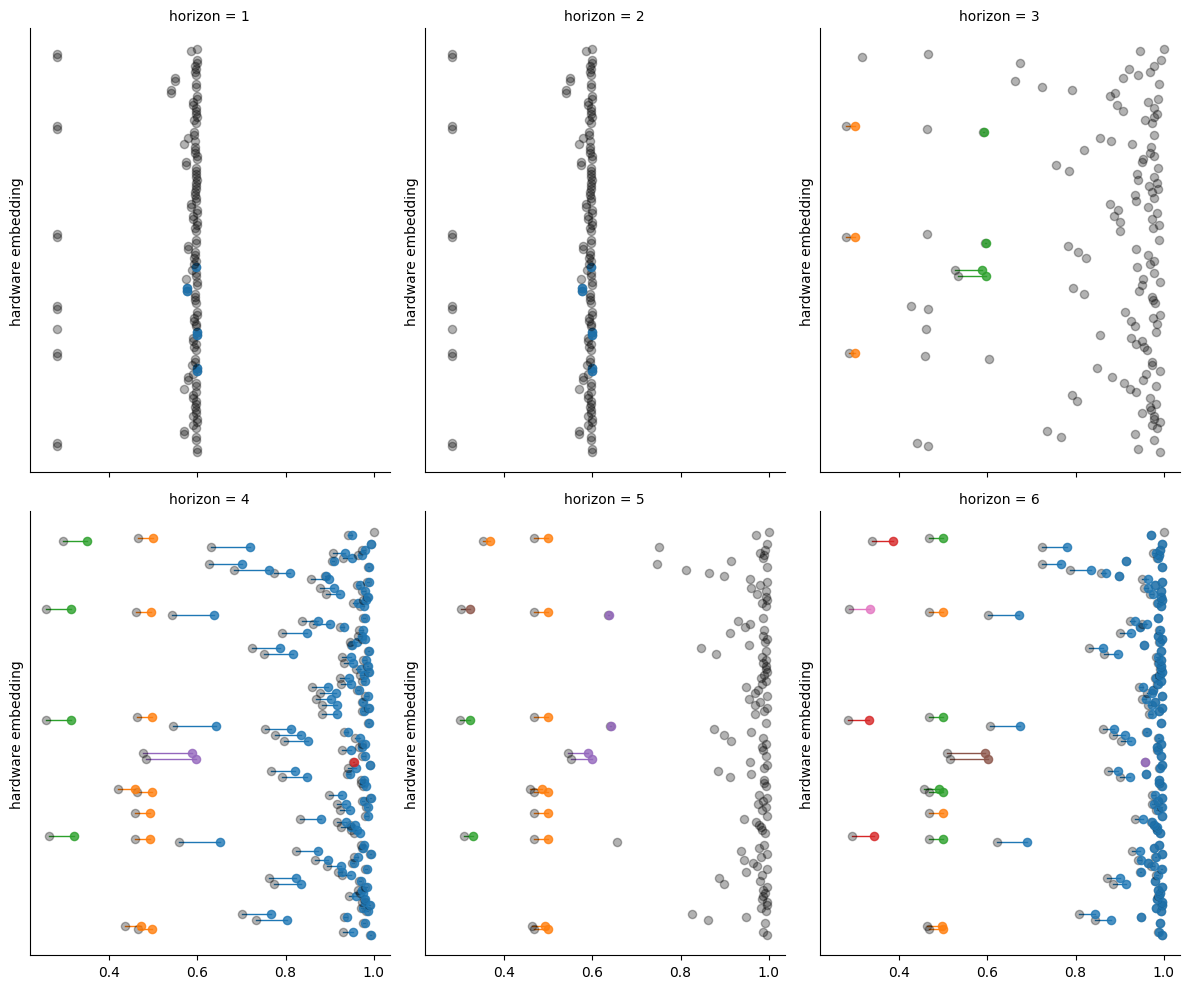

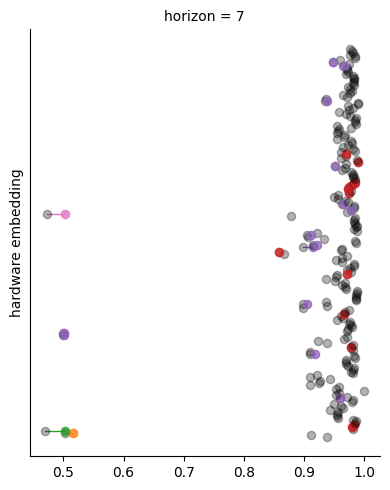

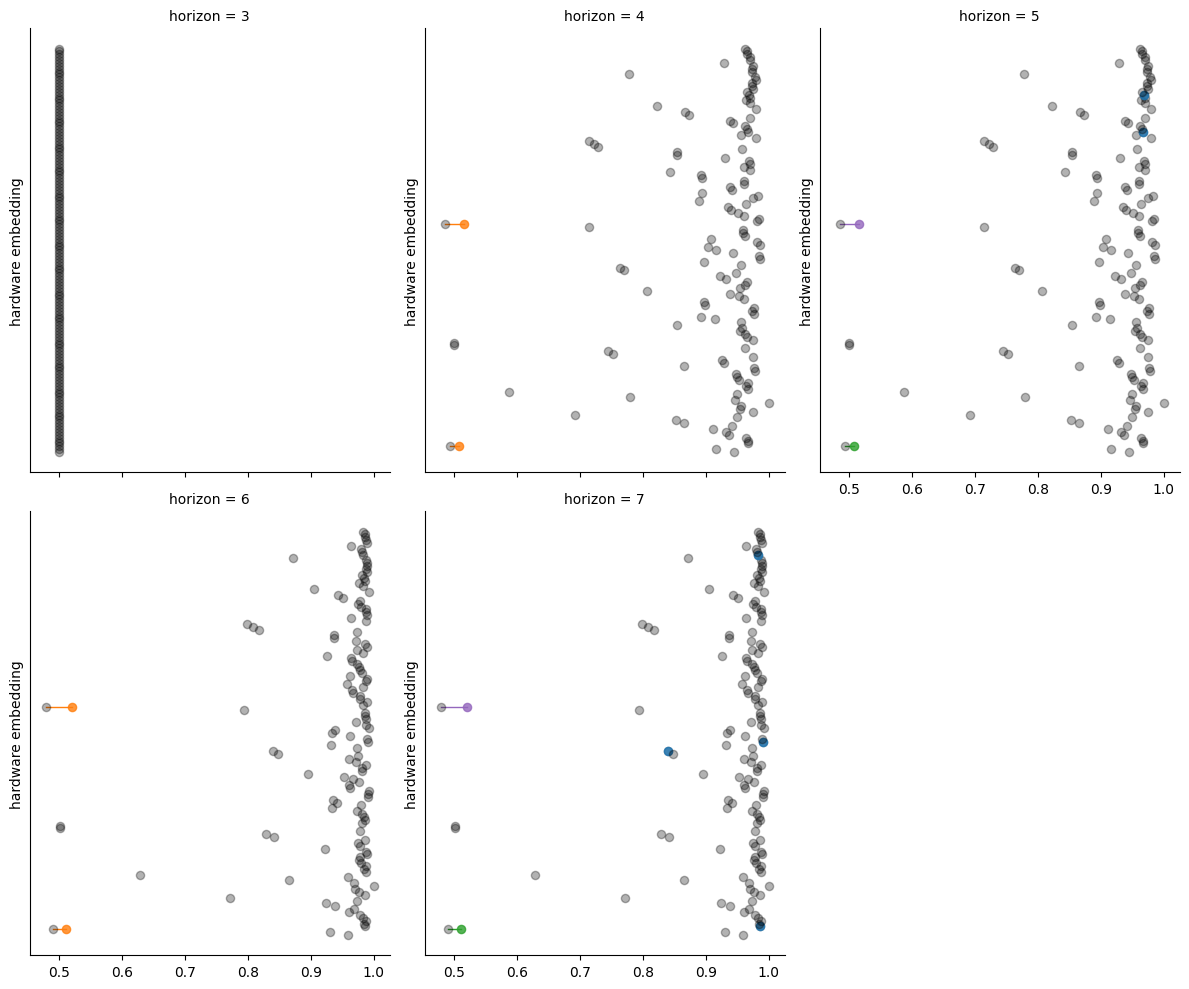

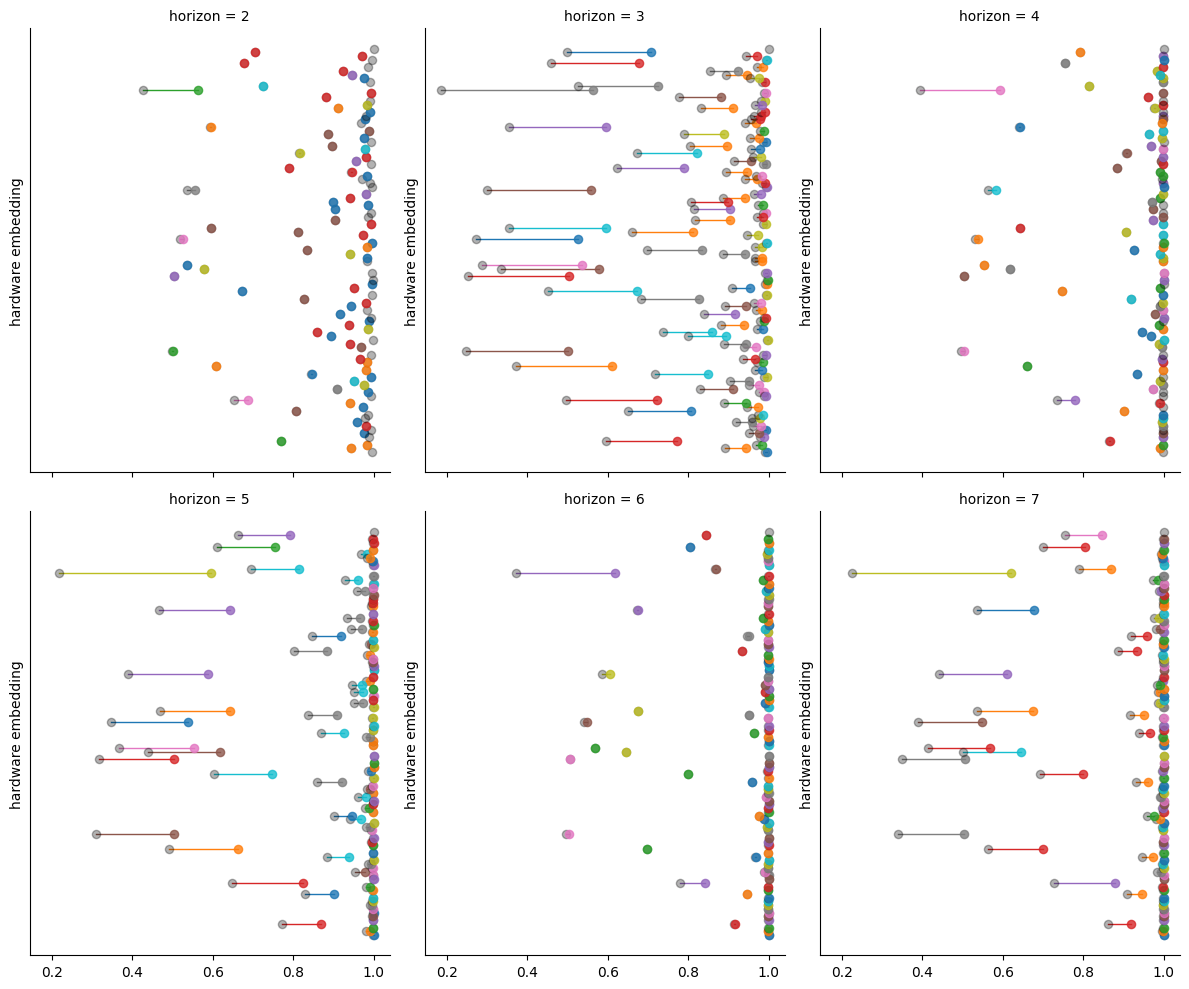

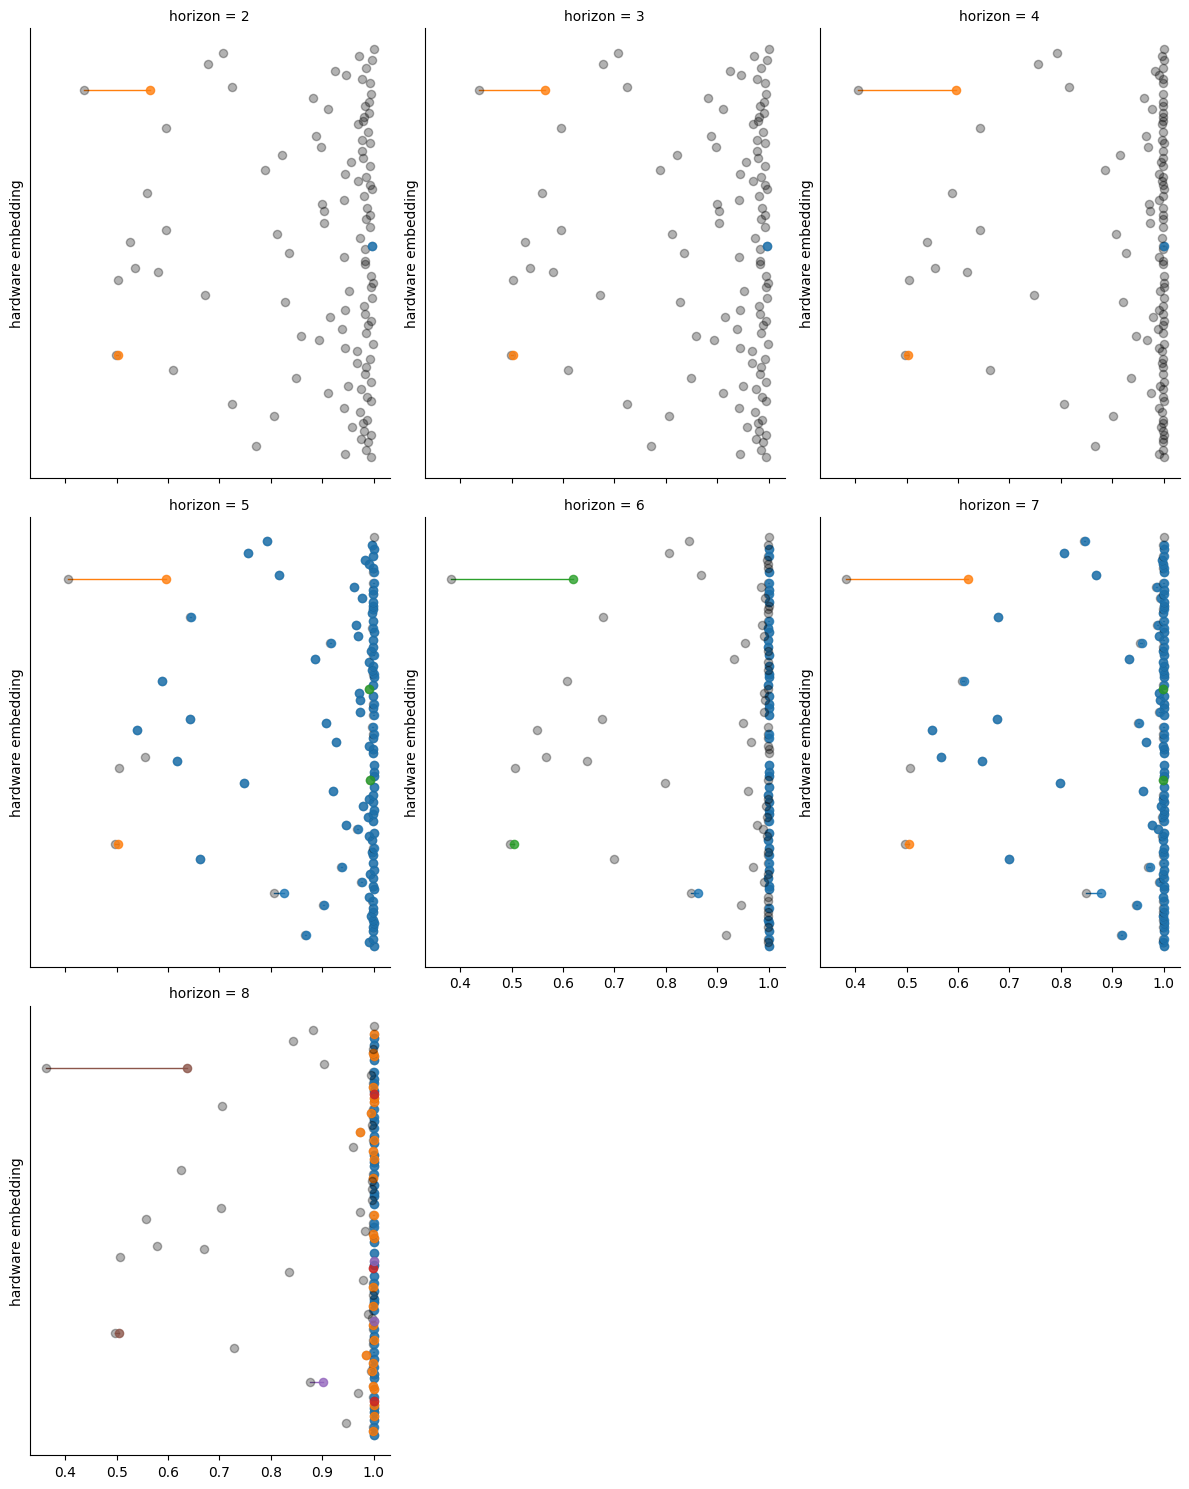

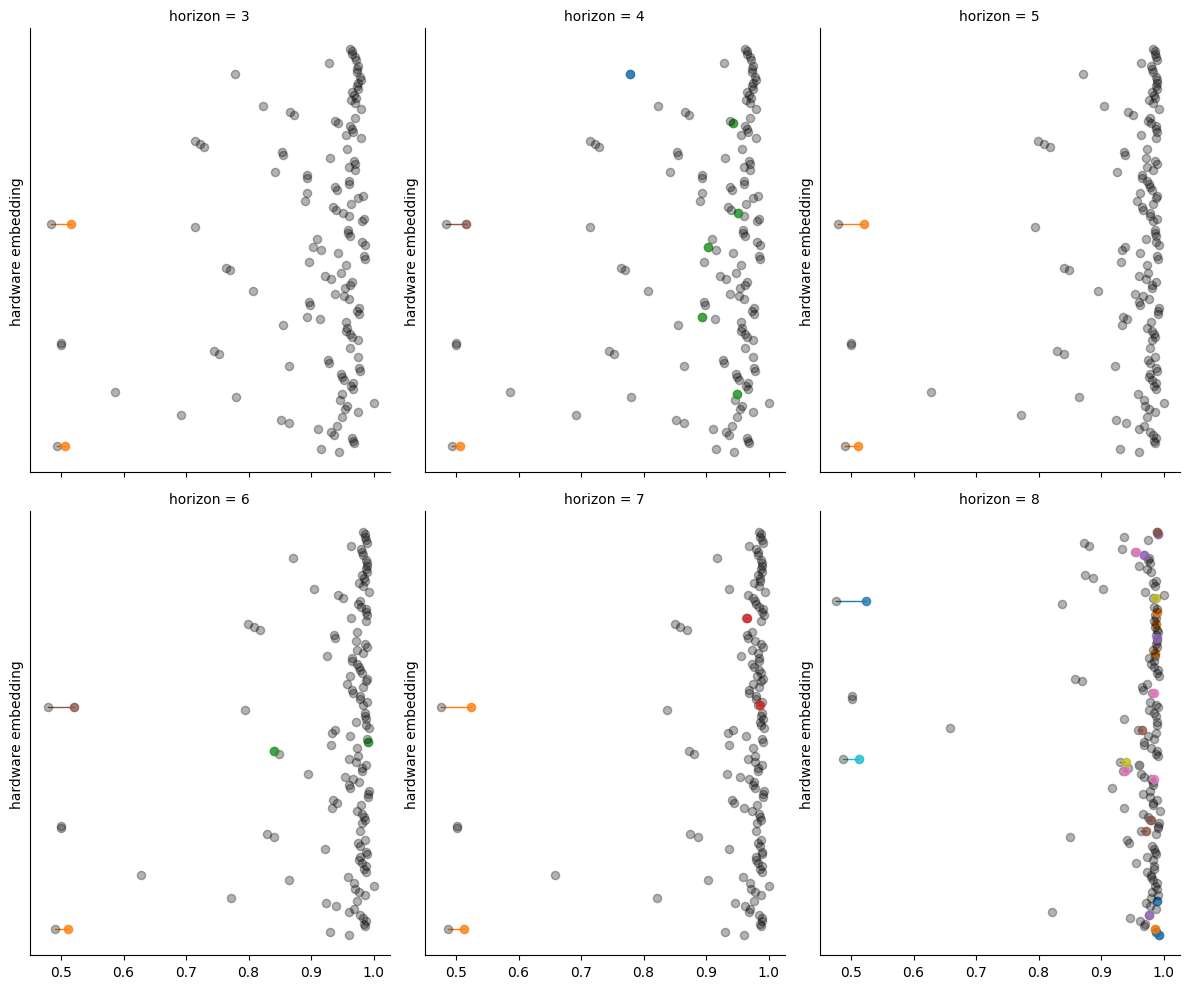

In [10]:
get_scatterplots()

### Count probabilistic algorithms synthesized via linear preconditions

In [2]:
import json


for experiment in Experiment:
    methods = get_methods_used(experiment)
    if "convex" in methods:
        f = open(get_improvements_path(experiment))
        lines = f.readlines()[1:]
        f.close()
        rows = []
        for line in lines:
            stat_line = StatsFileLine(line, FileType.improvements)
            if stat_line.method == "convex" and stat_line.hardware != "perfect_hardware":
                is_prob = 0
                prob_branch = 0
                # load algorithm file
                algorithm_file = open(os.path.join(get_experiment_path(experiment), "raw_algorithms", f"R_{stat_line.algorithm_index}.txt"))

                obj = json.load(algorithm_file)
                algorithm_file.close()
                if len(obj["children"]) > 0:
                    if obj["action"]["name"] == "RANDOM_BRANCH" and (obj["children_probs"][0][1] < 1):
                        is_prob = 1
                        prob_branch = obj["children_probs"][0][1]
                assert(stat_line.method == "convex")
                row = {
                    "hardware": stat_line.hardware,
                    "embedding_index": stat_line.embedding_index,
                    "horizon": stat_line.horizon,
                    "is_prob": is_prob,
                    "prob_branch": prob_branch,
                    "algorithm_index": stat_line.algorithm_index,
                    "baseline_index": stat_line.baseline_index,
                    "algorithm_prob": stat_line.algorithm_prob,
                    "baseline_prob": stat_line.baseline_prob,
                    "diff": round(stat_line.diff, 5),

                }
                rows.append(row)


        df = pd.DataFrame(rows)
        print(get_experiment_path(experiment), "prob_algs_stat.csv")
        df.to_csv(os.path.join(get_experiment_path(experiment), "prob_algs_stat.csv"), index=False)



basic_zero_plus_discr prob_algs_stat.csv
bell_state_reach prob_algs_stat.csv
reset prob_algs_stat.csv
